In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("D:\Steel Manufacturing\data\steel_manufacturing_dataset.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10100 entries, 0 to 10099
Data columns (total 35 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               10100 non-null  object 
 1   Batch_ID                10100 non-null  int64  
 2   Machine_ID              10100 non-null  object 
 3   Steel_Grade             10100 non-null  object 
 4   Shift                   10100 non-null  object 
 5   Operator_ID             10100 non-null  object 
 6   Air_Temp                10100 non-null  float64
 7   Furnace_Temp            10100 non-null  float64
 8   Cooling_Rate            9798 non-null   float64
 9   Rolling_Speed           10100 non-null  float64
 10  Pressure                9798 non-null   float64
 11  Carbon                  9796 non-null   float64
 12  Manganese               10100 non-null  float64
 13  Silicon                 10100 non-null  float64
 14  Sulfur                  10100 non-null

In [5]:
df.describe(include="all")

,Timestamp,Batch_ID,Machine_ID,Steel_Grade,Shift,Operator_ID,Air_Temp,Furnace_Temp,Cooling_Rate,Rolling_Speed,...,Power_kW,Lubricant_Level,Humidity,Tool_Wear,Days_Since_Maintenance,Previous_Failure_Count,Maintenance_Type,Inspection_Time_sec,Defect_Type,Pass_Fail
count,10100,10100.000000,10100,10100,10100,10100,10100.000000,10100.000000,9798.000000,10100.000000,...,10100.000000,10100.000000,10100.000000,10100.000000,10100.000000,10100.000000,10100,10100.000000,4375,10100
unique,10000,NaN,10,6,3,40,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,5,2
top,2025-02-18 22:45:00,NaN,M4,SS400,Night,OP31,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Inspection,NaN,Scratch,Pass
freq,2,NaN,1071,2024,3416,286,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,3386,NaN,930,5725
mean,NaN,104998.962277,NaN,NaN,NaN,NaN,27.959646,1543.683851,11.020860,3.604378,...,519.792618,60.135249,55.277143,501.056337,89.640693,0.984851,NaN,55.014507,NaN,NaN
std,NaN,2886.828406,NaN,NaN,NaN,NaN,5.038935,217.077274,1.816969,0.403425,...,15.119711,23.214159,14.569550,289.403371,52.404867,0.990633,NaN,7.981871,NaN,NaN
min,NaN,100000.000000,NaN,NaN,NaN,NaN,8.347271,1451.932249,3.884574,1.973914,...,463.733658,20.004364,30.003162,0.000000,0.000000,0.000000,NaN,20.494381,NaN,NaN
25%,NaN,102497.750000,NaN,NaN,NaN,NaN,24.504384,1507.721901,9.788243,3.330867,...,509.641572,39.775693,42.493099,249.000000,44.000000,0.000000,NaN,49.736830,NaN,NaN
50%,NaN,104997.500000,NaN,NaN,NaN,NaN,27.938235,1520.320782,11.008309,3.605324,...,519.664562,60.066709,55.560924,505.000000,89.000000,1.000000,NaN,54.980846,NaN,NaN
75%,NaN,107500.250000,NaN,NaN,NaN,NaN,31.406487,1532.196685,12.221850,3.879560,...,529.843034,80.508062,68.170282,748.000000,134.000000,2.000000,NaN,60.370702,NaN,NaN


In [6]:
df.isnull().sum()

Timestamp                    0
Batch_ID                     0
Machine_ID                   0
Steel_Grade                  0
Shift                        0
Operator_ID                  0
Air_Temp                     0
Furnace_Temp                 0
Cooling_Rate               302
Rolling_Speed                0
Pressure                   302
Carbon                     304
Manganese                    0
Silicon                      0
Sulfur                       0
Phosphorus                   0
Thickness                    0
Width                        0
Hardness                   303
Tensile_Strength             0
Yield_Strength               0
Elongation                   0
Vibration                    0
Current                      0
Voltage                      0
Power_kW                     0
Lubricant_Level              0
Humidity                     0
Tool_Wear                    0
Days_Since_Maintenance       0
Previous_Failure_Count       0
Maintenance_Type             0
Inspecti

In [7]:
df.duplicated().sum()

np.int64(100)

In [8]:
df.sample(10)

,Timestamp,Batch_ID,Machine_ID,Steel_Grade,Shift,Operator_ID,Air_Temp,Furnace_Temp,Cooling_Rate,Rolling_Speed,...,Power_kW,Lubricant_Level,Humidity,Tool_Wear,Days_Since_Maintenance,Previous_Failure_Count,Maintenance_Type,Inspection_Time_sec,Defect_Type,Pass_Fail
3021,2025-02-01 11:15:00,103021,M1,SS400,Night,OP21,32.708203,1529.112787,12.521202,3.806152,...,536.674248,58.180739,76.679871,565,176,1,PM,55.724187,Scratch,Fail
2564,2025-01-27 17:00:00,102564,M7,SS400,Day,OP06,20.710264,1519.225754,10.137775,3.579473,...,511.971741,37.534068,33.608688,703,180,0,PM,64.823181,NaN,Pass
3804,2025-02-09 15:00:00,103804,M7,AISI1018,Evening,OP32,30.164735,1545.293605,10.868733,3.112082,...,505.294590,21.644617,35.311059,838,172,0,Inspection,43.922965,NaN,Pass
7440,2025-03-19 12:00:00,107440,M1,A572,Night,OP36,25.371977,1538.162028,9.137250,3.345059,...,506.836300,55.392013,78.509187,174,51,1,CM,54.139580,Crack,Fail
4472,2025-02-16 14:00:00,104472,M5,A36,Evening,OP07,28.368974,1499.087887,10.795059,3.634348,...,518.044037,28.647018,79.942316,751,32,1,Inspection,54.248813,NaN,Pass
4004,2025-02-11 17:00:00,104004,M8,A36,Night,OP04,32.168861,1509.053402,11.686483,3.692189,...,514.645898,66.115936,40.986728,984,74,0,CM,57.124380,NaN,Pass
4128,2025-02-13 00:00:00,104128,M8,A572,Day,OP36,28.703560,1522.897702,8.776635,3.288295,...,496.577221,26.627371,73.624386,102,56,1,PM,53.929674,NaN,Pass
6029,2025-03-04 19:15:00,106029,M1,SS400,Night,OP14,23.220615,1524.864741,10.483449,3.613990,...,508.348033,41.853027,39.904227,123,129,0,PM,53.275538,NaN,Pass
260,2025-01-03 17:00:00,100260,M2,S355,Day,OP24,21.773391,1511.156755,9.299567,3.435690,...,531.067568,29.071773,76.059464,962,37,2,CM,46.035345,NaN,Pass
6706,2025-03-11 20:30:00,106706,M8,A36,Day,OP32,20.435048,1487.913490,6.660807,3.636110,...,503.944782,48.745183,44.659845,535,25,0,Inspection,57.191847,Inclusion,Fail


In [9]:
clean_df=df.copy()

In [10]:
duplicates =clean_df.duplicated().sum()
print("duplicates=", {duplicates})

duplicates= {np.int64(100)}


In [11]:
clean_df= clean_df.drop_duplicates()

In [12]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 9999
Data columns (total 35 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               10000 non-null  object 
 1   Batch_ID                10000 non-null  int64  
 2   Machine_ID              10000 non-null  object 
 3   Steel_Grade             10000 non-null  object 
 4   Shift                   10000 non-null  object 
 5   Operator_ID             10000 non-null  object 
 6   Air_Temp                10000 non-null  float64
 7   Furnace_Temp            10000 non-null  float64
 8   Cooling_Rate            9700 non-null   float64
 9   Rolling_Speed           10000 non-null  float64
 10  Pressure                9700 non-null   float64
 11  Carbon                  9700 non-null   float64
 12  Manganese               10000 non-null  float64
 13  Silicon                 10000 non-null  float64
 14  Sulfur                  10000 non-null  floa

In [13]:
clean_df["Timestamp"]= pd.to_datetime(clean_df["Timestamp"])

In [14]:
clean_df.dtypes

Timestamp                 datetime64[ns]
Batch_ID                           int64
Machine_ID                        object
Steel_Grade                       object
Shift                             object
Operator_ID                       object
Air_Temp                         float64
Furnace_Temp                     float64
Cooling_Rate                     float64
Rolling_Speed                    float64
Pressure                         float64
Carbon                           float64
Manganese                        float64
Silicon                          float64
Sulfur                           float64
Phosphorus                       float64
Thickness                        float64
Width                            float64
Hardness                         float64
Tensile_Strength                 float64
Yield_Strength                   float64
Elongation                       float64
Vibration                        float64
Current                          float64
Voltage         

In [15]:
clean_df["Steel_Grade"].unique()

array(['A572', 'A36', 'SS400', 'S355', 'AISI1018', ' a36 '], dtype=object)

In [16]:
clean_df["Steel_Grade"]= clean_df["Steel_Grade"].str.strip().str.upper()

In [17]:
categorical_collumns = [
    "Steel_Grade",
    "Shift",
    "Maintenance_Type",
    "Machine_ID",
    "Operator_ID"
]
for col in categorical_collumns:
    clean_df[col]= clean_df[col].astype(str).str.strip()

In [18]:
for col in categorical_collumns:
    print (col)
    print (clean_df[col].unique())
    print ("-"*5)

Steel_Grade
['A572' 'A36' 'SS400' 'S355' 'AISI1018']
-----
Shift
['Night' 'Evening' 'Day']
-----
Maintenance_Type
['PM' 'CM' 'Inspection']
-----
Machine_ID
['M3' 'M9' 'M4' 'M2' 'M1' 'M7' 'M5' 'M10' 'M8' 'M6']
-----
Operator_ID
['OP04' 'OP38' 'OP28' 'OP36' 'OP15' 'OP26' 'OP09' 'OP08' 'OP12' 'OP07'
 'OP14' 'OP30' 'OP16' 'OP20' 'OP39' 'OP11' 'OP05' 'OP23' 'OP06' 'OP25'
 'OP27' 'OP19' 'OP40' 'OP33' 'OP31' 'OP35' 'OP10' 'OP24' 'OP32' 'OP29'
 'OP22' 'OP01' 'OP13' 'OP02' 'OP17' 'OP18' 'OP03' 'OP37' 'OP34' 'OP21']
-----


In [19]:
missing = clean_df.isnull().sum()
missing = missing[missing>0]
missing.sort_values(ascending=False)

Defect_Type     5668
Cooling_Rate     300
Pressure         300
Carbon           300
Hardness         300
dtype: int64

In [20]:
# Caculate Percentage 
missing_percent = (clean_df.isnull().sum()/len(clean_df))*100

missing_df = pd.DataFrame({
    "Missing": clean_df.isnull().sum(),
    "Percent": missing_percent
})

missing_df[missing_df["Missing"]>0].sort_values("Percent",ascending=False)

,Missing,Percent
Defect_Type,5668,56.68
Cooling_Rate,300,3.00
Pressure,300,3.00
Carbon,300,3.00
Hardness,300,3.00


<Axes: >

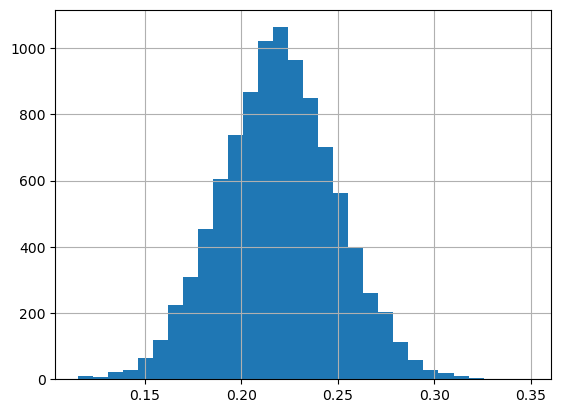

In [21]:
clean_df["Carbon"].hist(bins=30)

In [22]:
clean_df["Carbon"] = clean_df["Carbon"].fillna(clean_df["Carbon"].median())
clean_df["Pressure"] = clean_df["Pressure"].fillna(clean_df["Pressure"].median())
clean_df["Cooling_Rate"] = clean_df["Cooling_Rate"].fillna(clean_df["Cooling_Rate"].median())
clean_df["Hardness"] = clean_df["Hardness"].fillna(clean_df["Hardness"].median())

In [23]:
clean_df.isnull().sum()

Timestamp                    0
Batch_ID                     0
Machine_ID                   0
Steel_Grade                  0
Shift                        0
Operator_ID                  0
Air_Temp                     0
Furnace_Temp                 0
Cooling_Rate                 0
Rolling_Speed                0
Pressure                     0
Carbon                       0
Manganese                    0
Silicon                      0
Sulfur                       0
Phosphorus                   0
Thickness                    0
Width                        0
Hardness                     0
Tensile_Strength             0
Yield_Strength               0
Elongation                   0
Vibration                    0
Current                      0
Voltage                      0
Power_kW                     0
Lubricant_Level              0
Humidity                     0
Tool_Wear                    0
Days_Since_Maintenance       0
Previous_Failure_Count       0
Maintenance_Type             0
Inspecti

In [24]:
clean_df["Defect_Type"].value_counts(dropna=False)

Defect_Type
NaN          5668
Scratch       918
Inclusion     882
Scale         868
Crack         843
Pitting       821
Name: count, dtype: int64

In [25]:
clean_df["Pass_Fail"].value_counts(dropna=False)

Pass_Fail
Pass    5668
Fail    4332
Name: count, dtype: int64

In [26]:
clean_df.loc[
    (clean_df["Pass_Fail"] == "Pass") &
    (clean_df["Defect_Type"].isna()),
    "Defect_Type"
] = "None"

In [27]:
clean_df["Defect_Type"].value_counts(dropna=False)

Defect_Type
None         5668
Scratch       918
Inclusion     882
Scale         868
Crack         843
Pitting       821
Name: count, dtype: int64

In [28]:
clean_df["Defect_Type"].isnull().sum()

np.int64(0)

In [29]:
clean_df.isnull().sum().sort_values(ascending=False)

Timestamp                 0
Lubricant_Level           0
Yield_Strength            0
Elongation                0
Vibration                 0
Current                   0
Voltage                   0
Power_kW                  0
Humidity                  0
Hardness                  0
Tool_Wear                 0
Days_Since_Maintenance    0
Previous_Failure_Count    0
Maintenance_Type          0
Inspection_Time_sec       0
Defect_Type               0
Tensile_Strength          0
Width                     0
Batch_ID                  0
Cooling_Rate              0
Machine_ID                0
Steel_Grade               0
Shift                     0
Operator_ID               0
Air_Temp                  0
Furnace_Temp              0
Rolling_Speed             0
Thickness                 0
Pressure                  0
Carbon                    0
Manganese                 0
Silicon                   0
Sulfur                    0
Phosphorus                0
Pass_Fail                 0
dtype: int64

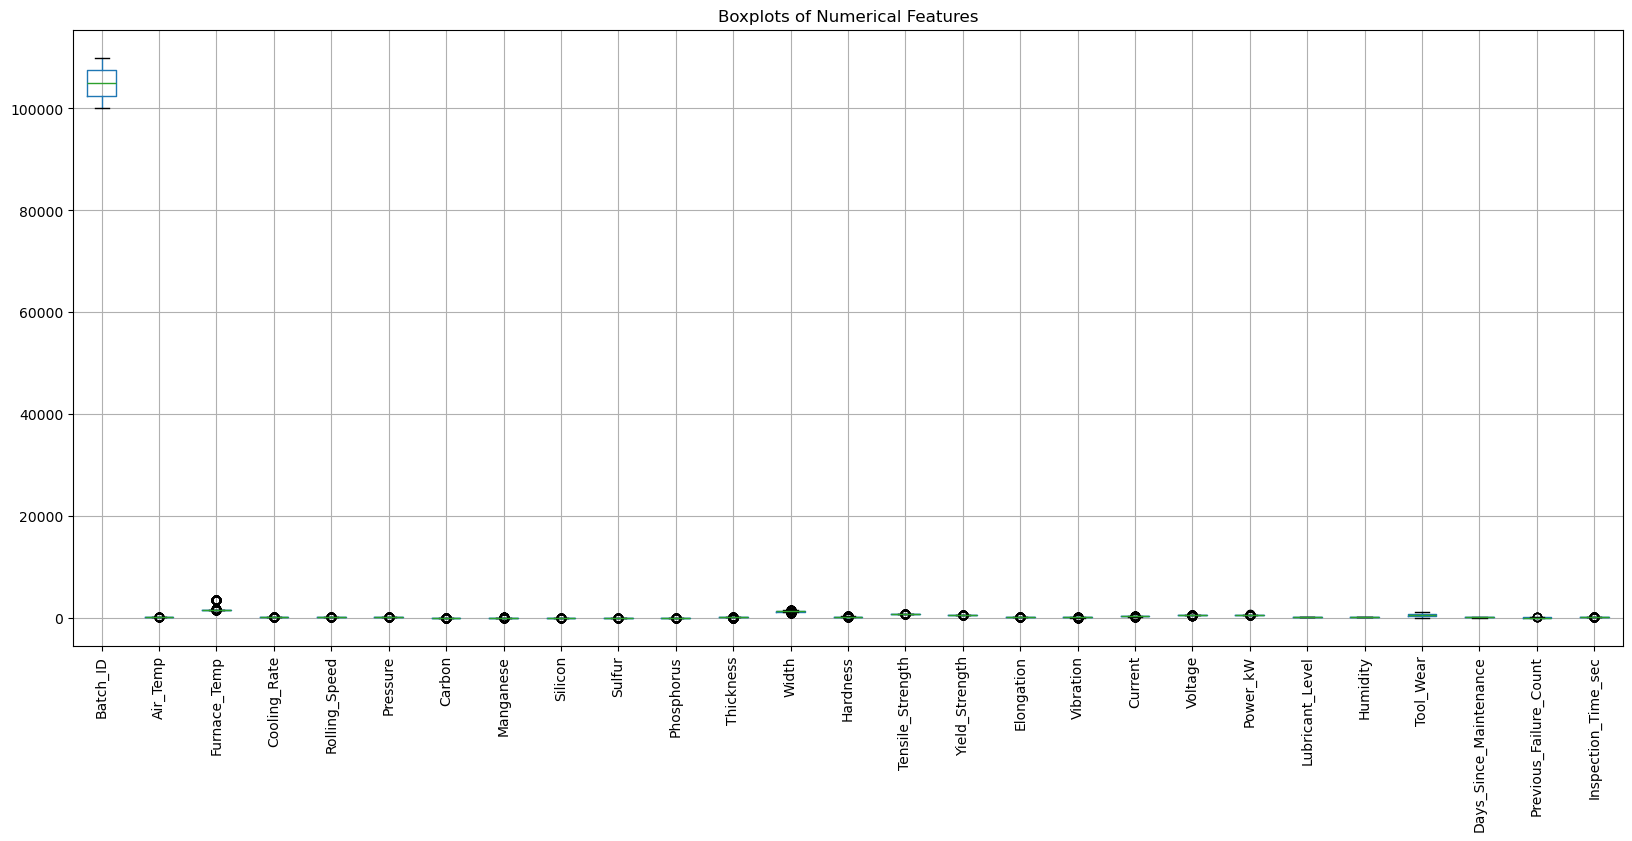

In [30]:
# Outliers Detection and Clearance 

import matplotlib.pyplot as plt

numerical_columns = clean_df.select_dtypes(include=["int64", "float64"]).columns

clean_df[numerical_columns].boxplot(figsize=(20, 8), rot=90)

plt.title("Boxplots of Numerical Features")
plt.show()

In [31]:
clean_df[clean_df["Thickness"] < 0]

,Timestamp,Batch_ID,Machine_ID,Steel_Grade,Shift,Operator_ID,Air_Temp,Furnace_Temp,Cooling_Rate,Rolling_Speed,...,Power_kW,Lubricant_Level,Humidity,Tool_Wear,Days_Since_Maintenance,Previous_Failure_Count,Maintenance_Type,Inspection_Time_sec,Defect_Type,Pass_Fail
91,2025-01-01 22:45:00,100091,M9,A572,Evening,OP40,33.117141,1518.327609,13.672773,3.616212,...,523.967862,63.545117,41.061718,782,14,1,PM,52.676249,None,Pass
179,2025-01-02 20:45:00,100179,M5,A36,Night,OP32,21.568065,1511.764862,9.638588,3.720630,...,507.581244,24.513164,44.812591,861,72,1,Inspection,65.972835,None,Pass
209,2025-01-03 04:15:00,100209,M8,SS400,Day,OP16,29.043269,1529.184100,11.095856,2.800217,...,526.121631,42.724054,72.578181,685,137,1,PM,53.776268,None,Pass
308,2025-01-04 05:00:00,100308,M10,SS400,Night,OP06,17.751968,1542.916732,10.930673,3.680120,...,503.584583,30.639080,70.337472,875,121,0,Inspection,53.489522,None,Pass
383,2025-01-04 23:45:00,100383,M5,A36,Day,OP03,34.617372,3500.000000,8.511577,3.556885,...,522.040051,47.873587,77.973728,488,137,3,PM,58.989198,Inclusion,Fail
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9721,2025-04-12 06:15:00,109721,M7,S355,Evening,OP11,33.873971,1567.092673,9.200241,3.402827,...,511.543795,81.938285,59.003570,771,4,0,CM,50.166774,Inclusion,Fail
9764,2025-04-12 17:00:00,109764,M6,S355,Day,OP10,32.899617,1458.428055,13.305592,3.181030,...,544.903844,88.396277,38.045146,923,133,0,Inspection,61.775261,Scale,Fail
9826,2025-04-13 08:30:00,109826,M2,A36,Night,OP14,30.235663,1523.459428,8.644458,3.443201,...,537.129717,25.833022,69.843438,612,65,0,PM,53.368087,None,Pass
9934,2025-04-14 11:30:00,109934,M10,S355,Evening,OP33,34.277003,1534.865191,14.003171,3.866313,...,514.595168,68.920204,64.676572,54,103,3,CM,47.661029,Pitting,Fail


In [32]:
clean_df[clean_df["Furnace_Temp"] > 2000]

,Timestamp,Batch_ID,Machine_ID,Steel_Grade,Shift,Operator_ID,Air_Temp,Furnace_Temp,Cooling_Rate,Rolling_Speed,...,Power_kW,Lubricant_Level,Humidity,Tool_Wear,Days_Since_Maintenance,Previous_Failure_Count,Maintenance_Type,Inspection_Time_sec,Defect_Type,Pass_Fail
171,2025-01-02 18:45:00,100171,M4,A572,Night,OP16,35.272513,3500.0,12.290690,3.848875,...,527.881299,72.365463,41.508244,402,126,0,Inspection,58.578853,None,Pass
304,2025-01-04 04:00:00,100304,M1,AISI1018,Evening,OP19,23.424661,3500.0,11.129058,4.555432,...,503.658984,31.524036,60.063243,405,92,2,PM,55.587394,None,Pass
383,2025-01-04 23:45:00,100383,M5,A36,Day,OP03,34.617372,3500.0,8.511577,3.556885,...,522.040051,47.873587,77.973728,488,137,3,PM,58.989198,Inclusion,Fail
481,2025-01-06 00:15:00,100481,M4,SS400,Night,OP37,32.573692,3500.0,13.097160,3.581412,...,532.332779,30.646087,71.366509,267,126,2,CM,49.452490,Crack,Fail
711,2025-01-08 09:45:00,100711,M7,A572,Night,OP15,29.464440,3500.0,11.192874,4.037033,...,518.439143,60.488549,52.616191,120,116,0,PM,51.800588,Inclusion,Fail
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9642,2025-04-11 10:30:00,109642,M8,AISI1018,Evening,OP17,26.105242,3500.0,9.150982,3.786712,...,526.735283,35.123743,60.918095,702,81,3,Inspection,64.155686,None,Pass
9739,2025-04-12 10:45:00,109739,M8,S355,Day,OP26,28.745298,3500.0,10.952765,3.637669,...,513.045964,39.007611,40.149037,148,178,1,Inspection,56.726374,Scratch,Fail
9881,2025-04-13 22:15:00,109881,M5,A36,Evening,OP23,28.092592,3500.0,8.333732,3.487721,...,546.717177,65.277621,40.130868,993,50,0,CM,59.404628,Pitting,Fail
9883,2025-04-13 22:45:00,109883,M7,A36,Evening,OP23,24.616098,3500.0,10.572343,3.505096,...,544.789837,27.968678,72.982748,422,55,1,CM,41.736318,None,Pass


## Count Outliers

In [33]:

def count_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return ((df[column] < lower) | (df[column] > upper)).sum()

In [34]:
numeric_columns = clean_df.select_dtypes(include=["number"]).columns

for col in numeric_columns:
    print(f"{col:30} {count_outliers(clean_df, col)}")

Batch_ID                       0
Air_Temp                       43
Furnace_Temp                   189
Cooling_Rate                   101
Rolling_Speed                  72
Pressure                       80
Carbon                         115
Manganese                      77
Silicon                        63
Sulfur                         69
Phosphorus                     74
Thickness                      186
Width                          79
Hardness                       116
Tensile_Strength               81
Yield_Strength                 81
Elongation                     93
Vibration                      74
Current                        68
Voltage                        86
Power_kW                       89
Lubricant_Level                0
Humidity                       0
Tool_Wear                      0
Days_Since_Maintenance         0
Previous_Failure_Count         5
Inspection_Time_sec            94


In [35]:
(clean_df["Furnace_Temp"] > 2000).sum()

(clean_df["Thickness"] < 0).sum()

np.int64(120)

In [36]:
clean_df.shape

(10000, 35)

In [37]:
import numpy as np

# Furnace temperature greater than 2000°C is impossible
clean_df.loc[
    clean_df["Furnace_Temp"] > 2000,
    "Furnace_Temp"
] = np.nan

# Negative thickness is impossible
clean_df.loc[
    clean_df["Thickness"] < 0,
    "Thickness"
] = np.nan

In [38]:
(clean_df["Furnace_Temp"] > 2000).sum()

(clean_df["Thickness"] < 0).sum()

np.int64(0)

## Impute Missing Values

In [39]:
clean_df["Furnace_Temp"] = (
    clean_df.groupby("Steel_Grade")["Furnace_Temp"]
    .transform(lambda x: x.fillna(x.median()))
)

clean_df["Thickness"] = (
    clean_df.groupby("Steel_Grade")["Thickness"]
    .transform(lambda x: x.fillna(x.median()))
)

In [40]:
# Missing values
clean_df.isnull().sum()

# Duplicate rows
clean_df.duplicated().sum()

# Impossible values
(clean_df["Furnace_Temp"] > 2000).sum()

(clean_df["Thickness"] < 0).sum()

np.int64(0)

# Feature Selection

In [41]:
X = clean_df.drop(columns=["Pass_Fail"])
y = clean_df["Pass_Fail"]

In [42]:
print("Features:", X.shape)
print("Target:", y.shape)

Features: (10000, 34)
Target: (10000,)


## Identification of Colomns that shouldn't be used 

In [43]:
X = X.drop(columns=["Defect_Type"])
X = X.drop(columns=["Batch_ID"])


In [44]:
print(X.shape)
print(y.shape)

(10000, 32)
(10000,)


In [45]:
categorical_features = X.select_dtypes(include=["object"]).columns

for col in categorical_features:
    print(f"\n{col}")
    print("Unique values:", X[col].nunique())
    print(X[col].unique())


Machine_ID
Unique values: 10
['M3' 'M9' 'M4' 'M2' 'M1' 'M7' 'M5' 'M10' 'M8' 'M6']

Steel_Grade
Unique values: 5
['A572' 'A36' 'SS400' 'S355' 'AISI1018']

Shift
Unique values: 3
['Night' 'Evening' 'Day']

Operator_ID
Unique values: 40
['OP04' 'OP38' 'OP28' 'OP36' 'OP15' 'OP26' 'OP09' 'OP08' 'OP12' 'OP07'
 'OP14' 'OP30' 'OP16' 'OP20' 'OP39' 'OP11' 'OP05' 'OP23' 'OP06' 'OP25'
 'OP27' 'OP19' 'OP40' 'OP33' 'OP31' 'OP35' 'OP10' 'OP24' 'OP32' 'OP29'
 'OP22' 'OP01' 'OP13' 'OP02' 'OP17' 'OP18' 'OP03' 'OP37' 'OP34' 'OP21']

Maintenance_Type
Unique values: 3
['PM' 'CM' 'Inspection']


In [46]:
X = X.drop(columns=["Operator_ID"])

In [47]:
categorical_features = X.select_dtypes(include=["object"]).columns

print(categorical_features)

Index(['Machine_ID', 'Steel_Grade', 'Shift', 'Maintenance_Type'], dtype='object')


In [48]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

print(numerical_features)

Index(['Air_Temp', 'Furnace_Temp', 'Cooling_Rate', 'Rolling_Speed', 'Pressure',
       'Carbon', 'Manganese', 'Silicon', 'Sulfur', 'Phosphorus', 'Thickness',
       'Width', 'Hardness', 'Tensile_Strength', 'Yield_Strength', 'Elongation',
       'Vibration', 'Current', 'Voltage', 'Power_kW', 'Lubricant_Level',
       'Humidity', 'Tool_Wear', 'Days_Since_Maintenance',
       'Previous_Failure_Count', 'Inspection_Time_sec'],
      dtype='object')


In [49]:
X_encoded = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True
)

In [50]:
X_encoded.head()

,Timestamp,Air_Temp,Furnace_Temp,Cooling_Rate,Rolling_Speed,Pressure,Carbon,Manganese,Silicon,Sulfur,...,Machine_ID_M8,Machine_ID_M9,Steel_Grade_A572,Steel_Grade_AISI1018,Steel_Grade_S355,Steel_Grade_SS400,Shift_Evening,Shift_Night,Maintenance_Type_Inspection,Maintenance_Type_PM
0,2025-01-01 00:00:00,28.010328,1550.429463,11.059076,4.410309,46.996016,0.206022,1.042768,0.360837,0.019184,...,False,False,True,False,False,False,False,True,False,True
1,2025-01-01 00:15:00,27.293967,1522.778040,14.652330,3.768521,45.768501,0.208386,0.894204,0.205985,0.022340,...,False,True,False,False,False,False,True,False,False,True
2,2025-01-01 00:30:00,37.967333,1532.401392,10.861093,4.090282,46.701977,0.251540,1.052476,0.261809,0.028357,...,False,False,False,False,False,False,False,False,False,False
3,2025-01-01 00:45:00,26.125589,1545.812482,11.009853,3.852121,51.305489,0.228733,1.085935,0.263092,0.022272,...,False,False,False,False,False,True,False,False,False,False
4,2025-01-01 01:00:00,34.408021,1513.123334,8.728593,3.683630,51.223095,0.257267,1.062680,0.297362,0.019354,...,False,False,False,False,True,False,False,False,True,False


# TimeStamp Analysis 

In [51]:
clean_df["Timestamp"] = pd.to_datetime(clean_df["Timestamp"])

In [52]:
clean_df["Hour"] = clean_df["Timestamp"].dt.hour
clean_df["Day_of_Week"] = clean_df["Timestamp"].dt.dayofweek
clean_df["Month"] = clean_df["Timestamp"].dt.month
clean_df["Day"] = clean_df["Timestamp"].dt.day


# Update X Encoded 

In [53]:
X = clean_df.drop(
    columns=[
        "Pass_Fail",
        "Defect_Type",
        "Batch_ID",
        "Operator_ID",
        "Timestamp",
        "Day"
    ]
)

y = clean_df["Pass_Fail"]


# Identification of Categorical Coloumns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

print(categorical_features)

Index(['Machine_ID', 'Steel_Grade', 'Shift', 'Maintenance_Type'], dtype='object')


In [54]:
# One Hot Encoding

X_encoded = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True
)

In [55]:
X_encoded.isnull().sum().sort_values(ascending=False)

Air_Temp                       0
Machine_ID_M6                  0
Inspection_Time_sec            0
Hour                           0
Day_of_Week                    0
Month                          0
Machine_ID_M10                 0
Machine_ID_M2                  0
Machine_ID_M3                  0
Machine_ID_M4                  0
Machine_ID_M5                  0
Machine_ID_M7                  0
Furnace_Temp                   0
Machine_ID_M8                  0
Machine_ID_M9                  0
Steel_Grade_A572               0
Steel_Grade_AISI1018           0
Steel_Grade_S355               0
Steel_Grade_SS400              0
Shift_Evening                  0
Shift_Night                    0
Maintenance_Type_Inspection    0
Previous_Failure_Count         0
Days_Since_Maintenance         0
Tool_Wear                      0
Humidity                       0
Cooling_Rate                   0
Rolling_Speed                  0
Pressure                       0
Carbon                         0
Manganese 

In [56]:
y.isnull().sum()

np.int64(0)

In [57]:
print(X_encoded.shape)
print(X_encoded.isnull().sum().sum())
print(y.value_counts())

(10000, 46)
0
Pass_Fail
Pass    5668
Fail    4332
Name: count, dtype: int64


# Sort Data by Time Stamp

In [58]:
clean_df = clean_df.sort_values("Timestamp").reset_index(drop=True)
clean_df[["Timestamp", "Pass_Fail"]].head()
clean_df[["Timestamp", "Pass_Fail"]].tail()

,Timestamp,Pass_Fail
9995,2025-04-15 02:45:00,Pass
9996,2025-04-15 03:00:00,Fail
9997,2025-04-15 03:15:00,Pass
9998,2025-04-15 03:30:00,Pass
9999,2025-04-15 03:45:00,Pass


### Recraeting X and Y

In [59]:
X = clean_df.drop(
    columns=[
        "Pass_Fail",
        "Defect_Type",
        "Batch_ID",
        "Operator_ID",
        "Timestamp",
        "Day"
    ]
)

y = clean_df["Pass_Fail"].map({
    "Pass": 0,
    "Fail": 1
})

## Categorical Features Identification 

In [60]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns

print(categorical_features)

Index(['Machine_ID', 'Steel_Grade', 'Shift', 'Maintenance_Type'], dtype='object')


### Encode Them 

In [61]:
X_encoded = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True
)
X_encoded = X_encoded.astype(float)

In [62]:
## Time Based Split

split_index = int(len(X_encoded) * 0.80)

X_train = X_encoded.iloc[:split_index]
X_test = X_encoded.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]



In [63]:
# Check Sizes

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8000, 46)
X_test: (2000, 46)
y_train: (8000,)
y_test: (2000,)


In [64]:
## Check Time Periods

print("Training period:")
print(clean_df["Timestamp"].iloc[:split_index].min())
print(clean_df["Timestamp"].iloc[:split_index].max())

print("\nTesting period:")
print(clean_df["Timestamp"].iloc[split_index:].min())
print(clean_df["Timestamp"].iloc[split_index:].max())

Training period:
2025-01-01 00:00:00
2025-03-25 07:45:00

Testing period:
2025-03-25 08:00:00
2025-04-15 03:45:00


In [65]:
## Check Target Distribution
print("Training:")
print(y_train.value_counts(normalize=True))

print("\nTesting:")
print(y_test.value_counts(normalize=True))

Training:
Pass_Fail
0    0.56675
1    0.43325
Name: proportion, dtype: float64

Testing:
Pass_Fail
0    0.567
1    0.433
Name: proportion, dtype: float64


In [66]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

(8000, 46)
(2000, 46)
Pass_Fail
0    4534
1    3466
Name: count, dtype: int64
Pass_Fail
0    1134
1     866
Name: count, dtype: int64


In [67]:
print(clean_df["Timestamp"].iloc[:split_index].min())
print(clean_df["Timestamp"].iloc[:split_index].max())

print(clean_df["Timestamp"].iloc[split_index:].min())
print(clean_df["Timestamp"].iloc[split_index:].max())

2025-01-01 00:00:00
2025-03-25 07:45:00
2025-03-25 08:00:00
2025-04-15 03:45:00


## Logical Linear Regression

In [68]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_log)

print("Accuracy:", accuracy)
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_log)

print(cm)
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_log,
        target_names=["Pass", "Fail"]
    )
)
from sklearn.metrics import roc_auc_score

y_prob_log = log_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob_log)

print("ROC-AUC:", roc_auc)


Accuracy: 0.6225
[[914 220]
 [535 331]]
              precision    recall  f1-score   support

        Pass       0.63      0.81      0.71      1134
        Fail       0.60      0.38      0.47       866

    accuracy                           0.62      2000
   macro avg       0.62      0.59      0.59      2000
weighted avg       0.62      0.62      0.60      2000

ROC-AUC: 0.632112206785032


c:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [69]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train, y_train)

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [70]:
y_pred_log = log_model.predict(X_test)

In [71]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred_log))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_log,
        target_names=["Pass", "Fail"]
    )
)

y_prob_log = log_model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

Accuracy: 0.6225

Confusion Matrix:
[[914 220]
 [535 331]]

Classification Report:
              precision    recall  f1-score   support

        Pass       0.63      0.81      0.71      1134
        Fail       0.60      0.38      0.47       866

    accuracy                           0.62      2000
   macro avg       0.62      0.59      0.59      2000
weighted avg       0.62      0.62      0.60      2000

ROC-AUC: 0.632112206785032


## Result

In [72]:
results = []

results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_log),
    "ROC_AUC": roc_auc_score(y_test, y_prob_log)
})

## Next Decision Tree

In [73]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_dt,
        target_names=["Pass", "Fail"]
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob_dt)
)

Accuracy: 0.8315

Confusion Matrix:
[[1047   87]
 [ 250  616]]

Classification Report:
              precision    recall  f1-score   support

        Pass       0.81      0.92      0.86      1134
        Fail       0.88      0.71      0.79       866

    accuracy                           0.83      2000
   macro avg       0.84      0.82      0.82      2000
weighted avg       0.84      0.83      0.83      2000

ROC-AUC: 0.8375088081593085


## Checking the Patterns

In [74]:
y_train_pred_dt = dt_model.predict(X_train)
train_accuracy_dt = accuracy_score(
    y_train,
    y_train_pred_dt
)

print("Training Accuracy:", train_accuracy_dt)
print("Testing Accuracy:", accuracy_score(y_test, y_pred_dt))
y_train_prob_dt = dt_model.predict_proba(X_train)[:, 1]

print(
    "Training ROC-AUC:",
    roc_auc_score(y_train, y_train_prob_dt)
)

print(
    "Testing ROC-AUC:",
    roc_auc_score(y_test, y_prob_dt)
)


Training Accuracy: 0.830125
Testing Accuracy: 0.8315
Training ROC-AUC: 0.8406982277393271
Testing ROC-AUC: 0.8375088081593085


In [75]:
y_train_pred_dt = dt_model.predict(X_train)

print(
    "Training Accuracy:",
    accuracy_score(y_train, y_train_pred_dt)
)

print(
    "Testing Accuracy:",
    accuracy_score(y_test, y_pred_dt)
)
y_train_prob_dt = dt_model.predict_proba(X_train)[:, 1]

print(
    "Training ROC-AUC:",
    roc_auc_score(y_train, y_train_prob_dt)
)

print(
    "Testing ROC-AUC:",
    roc_auc_score(y_test, y_prob_dt)
)

Training Accuracy: 0.830125
Testing Accuracy: 0.8315
Training ROC-AUC: 0.8406982277393271
Testing ROC-AUC: 0.8375088081593085


## Comparison

In [76]:
results = []

results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_log),
    "Fail_Precision": 0.60,
    "Fail_Recall": 0.38,
    "Fail_F1": 0.47,
    "ROC_AUC": roc_auc_score(y_test, y_prob_log)
})

results.append({
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(y_test, y_pred_dt),
    "Fail_Precision": 0.88,
    "Fail_Recall": 0.71,
    "Fail_F1": 0.79,
    "ROC_AUC": roc_auc_score(y_test, y_prob_dt)
})

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Fail_Precision,Fail_Recall,Fail_F1,ROC_AUC
0,Logistic Regression,0.6225,0.60,0.38,0.47,0.632112
1,Decision Tree,0.8315,0.88,0.71,0.79,0.837509


In [77]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Accuracy: 0.849

Confusion Matrix:
[[1087   47]
 [ 255  611]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.96      0.88      1134
           1       0.93      0.71      0.80       866

    accuracy                           0.85      2000
   macro avg       0.87      0.83      0.84      2000
weighted avg       0.86      0.85      0.85      2000

ROC-AUC: 0.9055271454232193


In [78]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(15))

             Feature  Importance
1       Furnace_Temp    0.224109
5             Carbon    0.121039
2       Cooling_Rate    0.079432
16         Vibration    0.047932
13  Tensile_Strength    0.028095
12          Hardness    0.027278
14    Yield_Strength    0.026682
7            Silicon    0.021536
10         Thickness    0.021361
6          Manganese    0.021361
4           Pressure    0.021253
11             Width    0.021207
15        Elongation    0.021009
0           Air_Temp    0.020982
20   Lubricant_Level    0.020946


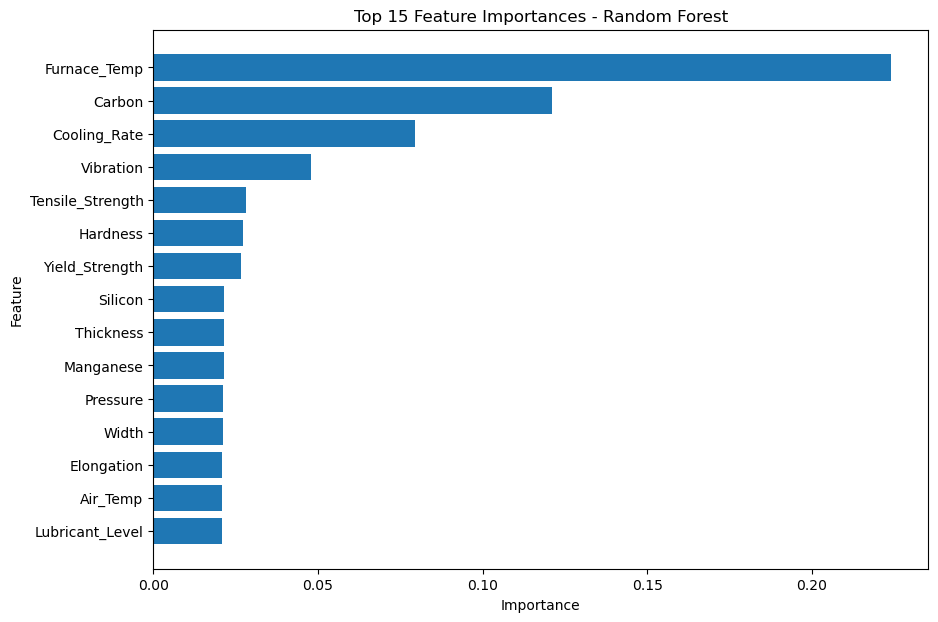

In [79]:
top_features = feature_importance.head(15).sort_values(
    by='Importance'
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 15 Feature Importances - Random Forest')

plt.show()

In [80]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Display top 15
print(feature_importance.head(15))

             Feature  Importance
1       Furnace_Temp    0.224109
5             Carbon    0.121039
2       Cooling_Rate    0.079432
16         Vibration    0.047932
13  Tensile_Strength    0.028095
12          Hardness    0.027278
14    Yield_Strength    0.026682
7            Silicon    0.021536
10         Thickness    0.021361
6          Manganese    0.021361
4           Pressure    0.021253
11             Width    0.021207
15        Elongation    0.021009
0           Air_Temp    0.020982
20   Lubricant_Level    0.020946


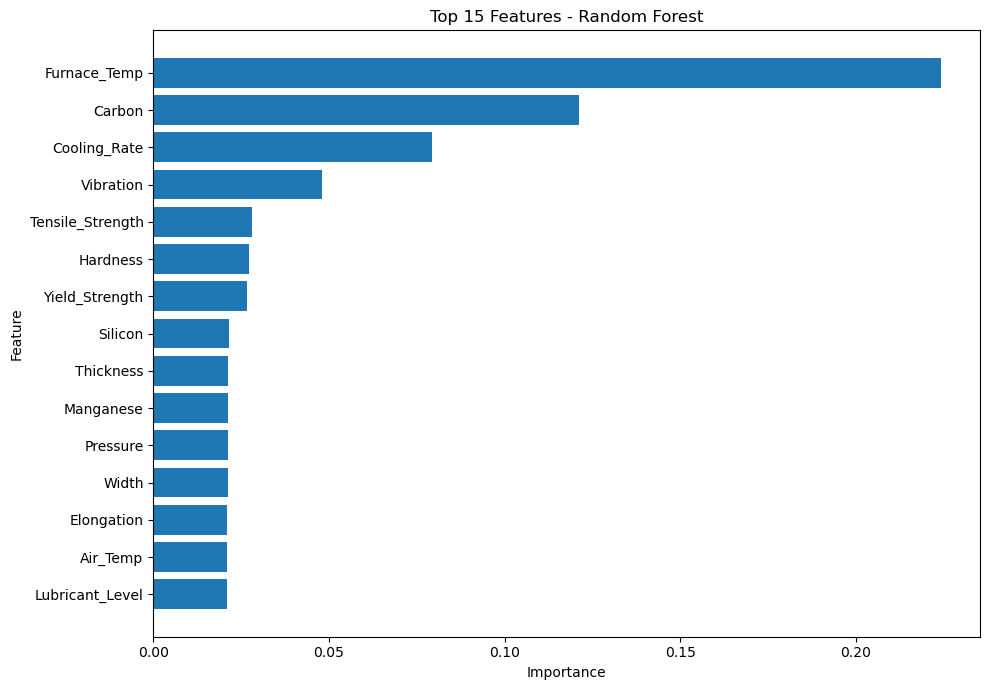

In [81]:
top_features = feature_importance.head(15).sort_values(
    by='Importance'
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 15 Features - Random Forest')

plt.tight_layout()
plt.show()

In [82]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


In [83]:
import shap
import matplotlib.pyplot as plt

In [84]:
explainer = shap.TreeExplainer(rf_model)

In [85]:
shap_values = explainer.shap_values(X_test)

In [86]:
if isinstance(shap_values, list):
    shap_values_fail = shap_values[1]
else:
    shap_values_fail = shap_values[:, :, 1]

In [87]:
if isinstance(shap_values, list):
    shap_values_fail = shap_values[1]
else:
    shap_values_fail = shap_values[:, :, 1]

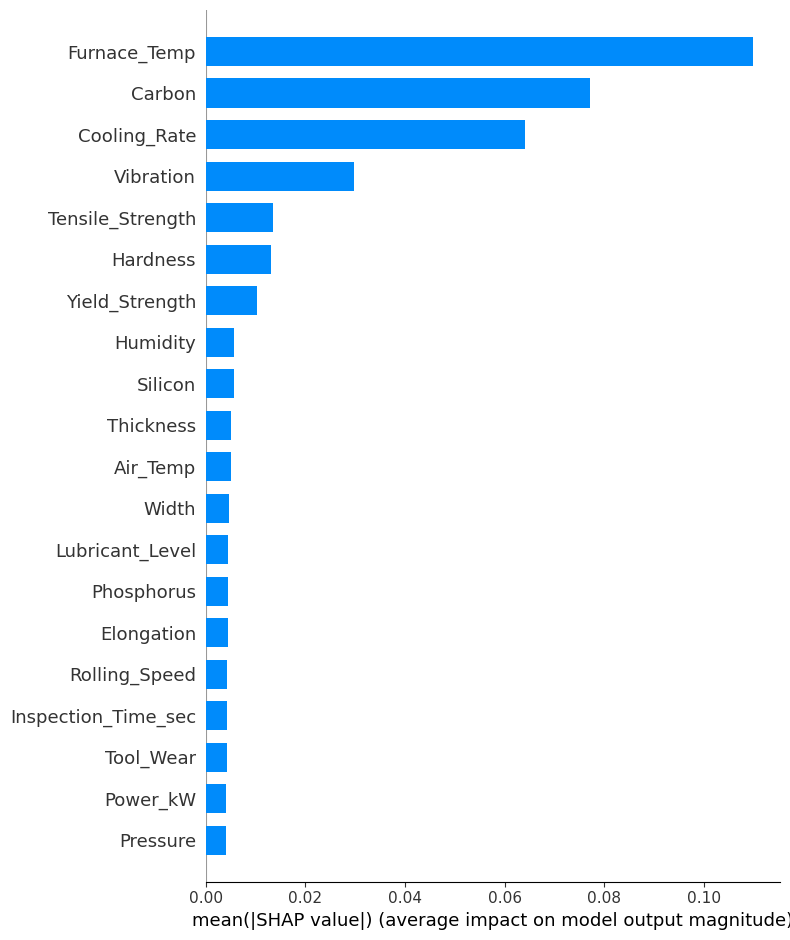

In [88]:
shap.summary_plot(
    shap_values_fail,
    X_test,
    plot_type="bar"
)

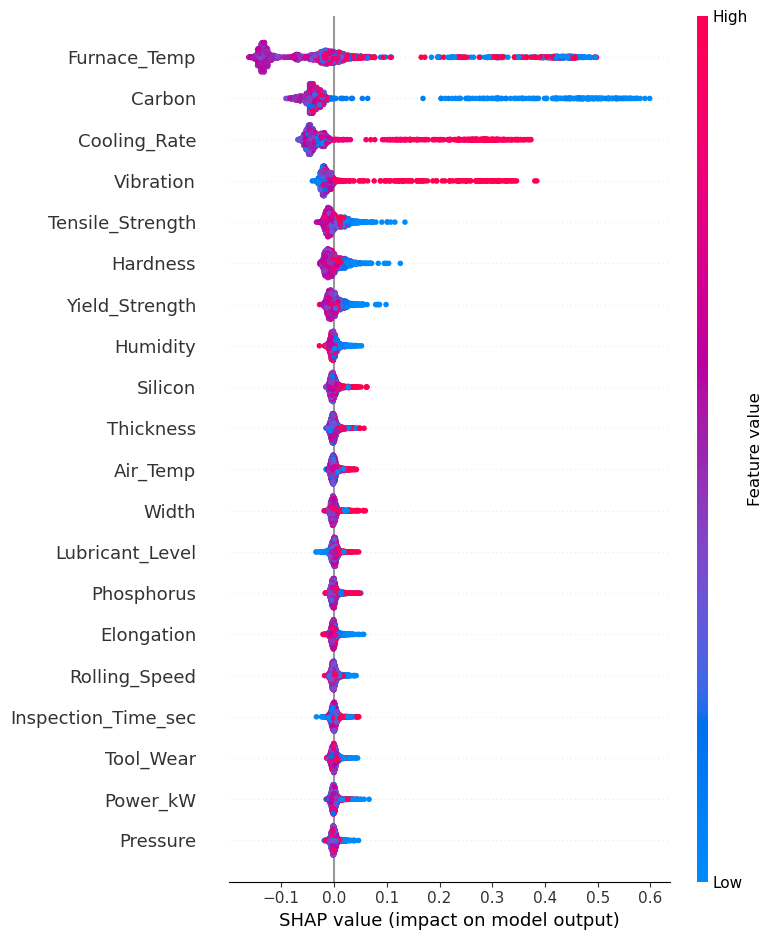

In [89]:
shap.summary_plot(
    shap_values_fail,
    X_test
)

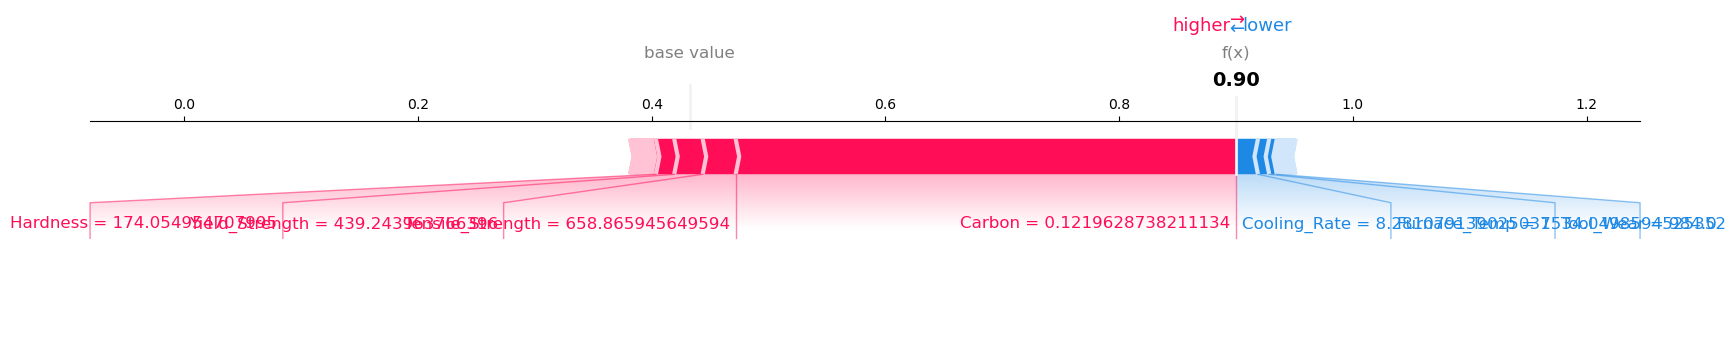

In [90]:
sample_index = 0

shap.force_plot(
    explainer.expected_value[1],
    shap_values_fail[sample_index],
    X_test.iloc[sample_index],
    matplotlib=True
)

plt.show()

In [91]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_test)

In [92]:
print(type(shap_values))

if isinstance(shap_values, list):
    print("Number of classes:", len(shap_values))
    print("Class 1 shape:", shap_values[1].shape)
else:
    print("SHAP shape:", shap_values.shape)

<class 'numpy.ndarray'>
SHAP shape: (2000, 46, 2)


In [93]:
if isinstance(shap_values, list):
    shap_values_fail = shap_values[1]
else:
    shap_values_fail = shap_values[:, :, 1]

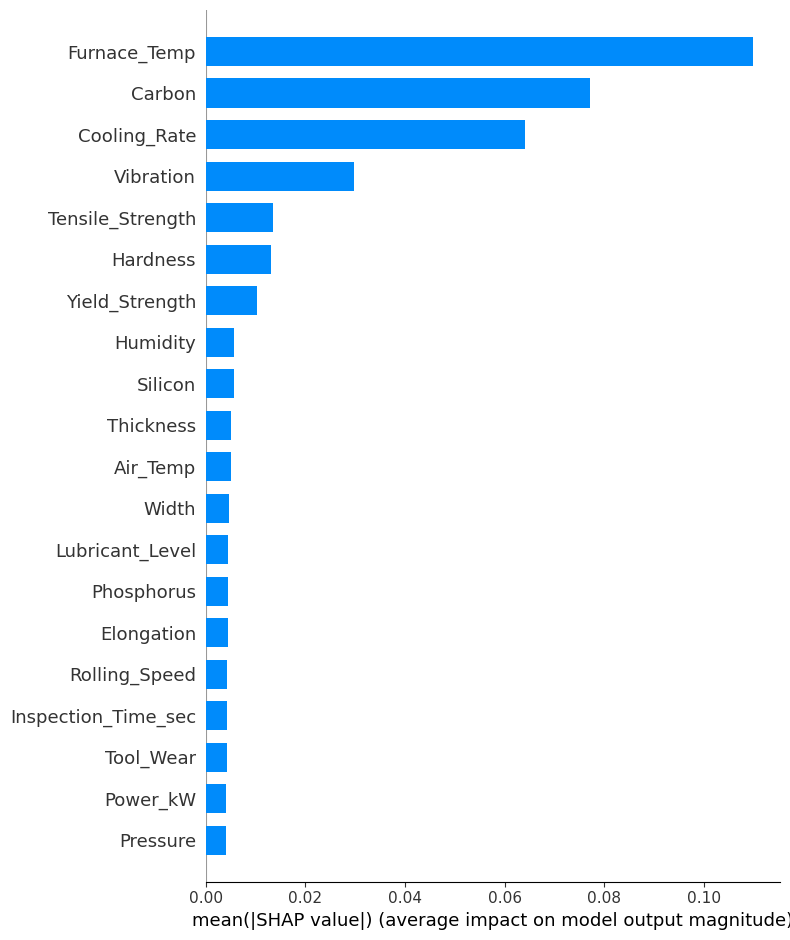

In [94]:
shap.summary_plot(
    shap_values_fail,
    X_test,
    plot_type="bar"
)

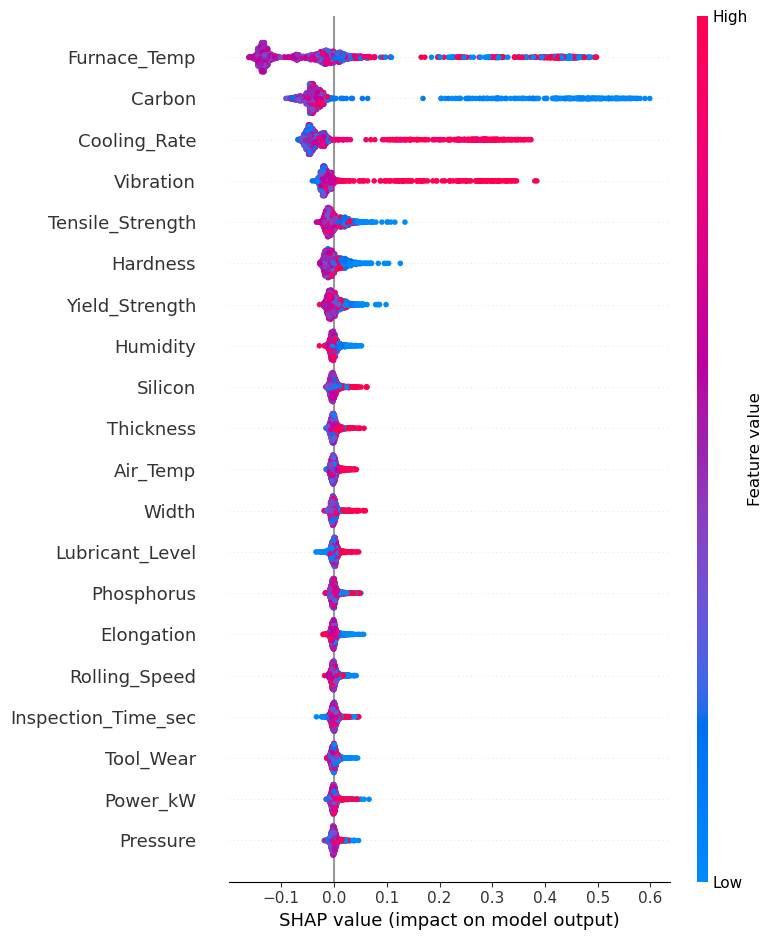

In [95]:
shap.summary_plot(
    shap_values_fail,
    X_test
)

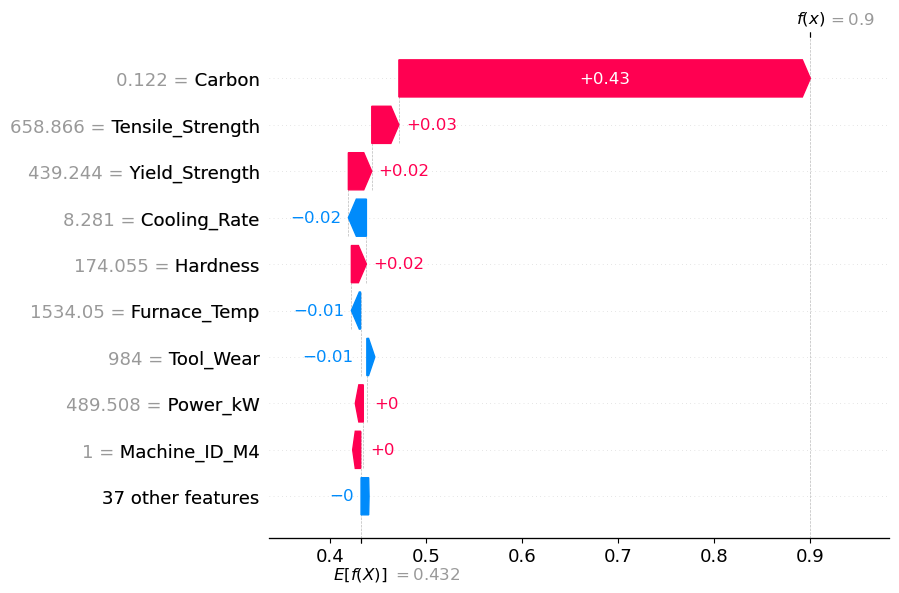

In [96]:
sample_index = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_fail[sample_index],
        base_values=explainer.expected_value[1],
        data=X_test.iloc[sample_index],
        feature_names=X_test.columns
    )
)

In [97]:
maintenance_features = [
    'Vibration',
    'Tool_Wear',
    'Days_Since_Maintenance',
    'Previous_Failure_Count',
    'Lubricant_Level'
]

df[maintenance_features].describe()

,Vibration,Tool_Wear,Days_Since_Maintenance,Previous_Failure_Count,Lubricant_Level
count,10100.000000,10100.000000,10100.000000,10100.000000,10100.000000
mean,2.199755,501.056337,89.640693,0.984851,60.135249
std,0.498848,289.403371,52.404867,0.990633,23.214159
min,0.203088,0.000000,0.000000,0.000000,20.004364
25%,1.865683,249.000000,44.000000,0.000000,39.775693
50%,2.199399,505.000000,89.000000,1.000000,60.066709
75%,2.531979,748.000000,134.000000,2.000000,80.508062
max,4.138280,1000.000000,180.000000,7.000000,99.991413


In [98]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_maintenance = df[maintenance_features].copy()

df_scaled = pd.DataFrame(
    scaler.fit_transform(df_maintenance),
    columns=maintenance_features,
    index=df.index
)

In [99]:
df['Maintenance_Risk_Score'] = (
    0.30 * df_scaled['Vibration'] +
    0.25 * df_scaled['Tool_Wear'] +
    0.20 * df_scaled['Days_Since_Maintenance'] +
    0.15 * df_scaled['Previous_Failure_Count'] +
    0.10 * (1 - df_scaled['Lubricant_Level'])
)

In [100]:
threshold = df['Maintenance_Risk_Score'].quantile(0.80)

df['Machine_Failure'] = (
    df['Maintenance_Risk_Score'] >= threshold
).astype(int)

In [101]:
print(df['Machine_Failure'].value_counts())

Machine_Failure
0    8080
1    2020
Name: count, dtype: int64


In [102]:
maintenance_features = [
    'Vibration',
    'Tool_Wear',
    'Days_Since_Maintenance',
    'Previous_Failure_Count',
    'Lubricant_Level',
    'Current',
    'Voltage',
    'Power_kW'
]

X_maintenance = df[maintenance_features]
y_maintenance = df['Machine_Failure']

In [103]:
from sklearn.model_selection import train_test_split

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_maintenance,
    y_maintenance,
    test_size=0.20,
    random_state=42,
    stratify=y_maintenance
)

In [104]:
#Logical Regresion
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

maintenance_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

maintenance_lr.fit(X_train_m, y_train_m)

y_pred_m_lr = maintenance_lr.predict(X_test_m)
y_prob_m_lr = maintenance_lr.predict_proba(X_test_m)[:, 1]

print("Accuracy:", accuracy_score(y_test_m, y_pred_m_lr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_m, y_pred_m_lr))

print("\nClassification Report:")
print(classification_report(y_test_m, y_pred_m_lr))

print("ROC-AUC:", roc_auc_score(y_test_m, y_prob_m_lr))

Accuracy: 0.9965346534653465

Confusion Matrix:
[[1611    5]
 [   2  402]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1616
           1       0.99      1.00      0.99       404

    accuracy                           1.00      2020
   macro avg       0.99      1.00      0.99      2020
weighted avg       1.00      1.00      1.00      2020

ROC-AUC: 0.9999678340358789


In [105]:
maintenance_results = []

maintenance_results.append({
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test_m, y_pred_m_lr),
    'Failure_Precision': classification_report(
        y_test_m, y_pred_m_lr, output_dict=True
    )['1']['precision'],
    'Failure_Recall': classification_report(
        y_test_m, y_pred_m_lr, output_dict=True
    )['1']['recall'],
    'Failure_F1': classification_report(
        y_test_m, y_pred_m_lr, output_dict=True
    )['1']['f1-score'],
    'ROC_AUC': roc_auc_score(y_test_m, y_prob_m_lr)
})

maintenance_results_df = pd.DataFrame(maintenance_results)

maintenance_results_df

,Model,Accuracy,Failure_Precision,Failure_Recall,Failure_F1,ROC_AUC
0,Logistic Regression,0.996535,0.987715,0.99505,0.991369,0.999968


In [106]:
#Random Forest 

from sklearn.ensemble import RandomForestClassifier

maintenance_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

maintenance_rf.fit(X_train_m, y_train_m)

y_pred_m_rf = maintenance_rf.predict(X_test_m)
y_prob_m_rf = maintenance_rf.predict_proba(X_test_m)[:, 1]

print("Accuracy:", accuracy_score(y_test_m, y_pred_m_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_m, y_pred_m_rf))

print("\nClassification Report:")
print(classification_report(y_test_m, y_pred_m_rf))

print("ROC-AUC:", roc_auc_score(y_test_m, y_prob_m_rf))

Accuracy: 0.9603960396039604

Confusion Matrix:
[[1603   13]
 [  67  337]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1616
           1       0.96      0.83      0.89       404

    accuracy                           0.96      2020
   macro avg       0.96      0.91      0.93      2020
weighted avg       0.96      0.96      0.96      2020

ROC-AUC: 0.9938409837270855


In [107]:
maintenance_results.append({
    'Model': 'Random Forest',
    'Accuracy': accuracy_score(y_test_m, y_pred_m_rf),
    'Failure_Precision': classification_report(
        y_test_m, y_pred_m_rf, output_dict=True
    )['1']['precision'],
    'Failure_Recall': classification_report(
        y_test_m, y_pred_m_rf, output_dict=True
    )['1']['recall'],
    'Failure_F1': classification_report(
        y_test_m, y_pred_m_rf, output_dict=True
    )['1']['f1-score'],
    'ROC_AUC': roc_auc_score(y_test_m, y_prob_m_rf)
})

maintenance_results_df = pd.DataFrame(maintenance_results)

maintenance_results_df

,Model,Accuracy,Failure_Precision,Failure_Recall,Failure_F1,ROC_AUC
0,Logistic Regression,0.996535,0.987715,0.995050,0.991369,0.999968
1,Random Forest,0.960396,0.962857,0.834158,0.893899,0.993841


In [108]:
# Gradient Boosting

from sklearn.ensemble import GradientBoostingClassifier

maintenance_gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

maintenance_gb.fit(X_train_m, y_train_m)

y_pred_m_gb = maintenance_gb.predict(X_test_m)
y_prob_m_gb = maintenance_gb.predict_proba(X_test_m)[:, 1]

print("Accuracy:", accuracy_score(y_test_m, y_pred_m_gb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_m, y_pred_m_gb))

print("\nClassification Report:")
print(classification_report(y_test_m, y_pred_m_gb))

print("ROC-AUC:", roc_auc_score(y_test_m, y_prob_m_gb))

Accuracy: 0.9727722772277227

Confusion Matrix:
[[1604   12]
 [  43  361]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1616
           1       0.97      0.89      0.93       404

    accuracy                           0.97      2020
   macro avg       0.97      0.94      0.96      2020
weighted avg       0.97      0.97      0.97      2020

ROC-AUC: 0.9960680938143319


In [109]:
maintenance_results.append({
    'Model': 'Gradient Boosting',
    'Accuracy': accuracy_score(y_test_m, y_pred_m_gb),
    'Failure_Precision': classification_report(
        y_test_m, y_pred_m_gb, output_dict=True
    )['1']['precision'],
    'Failure_Recall': classification_report(
        y_test_m, y_pred_m_gb, output_dict=True
    )['1']['recall'],
    'Failure_F1': classification_report(
        y_test_m, y_pred_m_gb, output_dict=True
    )['1']['f1-score'],
    'ROC_AUC': roc_auc_score(y_test_m, y_prob_m_gb)
})

maintenance_results_df = pd.DataFrame(maintenance_results)

maintenance_results_df

,Model,Accuracy,Failure_Precision,Failure_Recall,Failure_F1,ROC_AUC
0,Logistic Regression,0.996535,0.987715,0.995050,0.991369,0.999968
1,Random Forest,0.960396,0.962857,0.834158,0.893899,0.993841
2,Gradient Boosting,0.972772,0.967828,0.893564,0.929215,0.996068


In [110]:
maintenance_importance = pd.DataFrame({
    'Feature': X_train_m.columns,
    'Importance': maintenance_rf.feature_importances_
})

maintenance_importance = maintenance_importance.sort_values(
    by='Importance',
    ascending=False
)

print(maintenance_importance)

                  Feature  Importance
1               Tool_Wear    0.393265
2  Days_Since_Maintenance    0.253947
0               Vibration    0.131689
4         Lubricant_Level    0.085000
3  Previous_Failure_Count    0.035270
5                 Current    0.034616
6                 Voltage    0.033603
7                Power_kW    0.032611


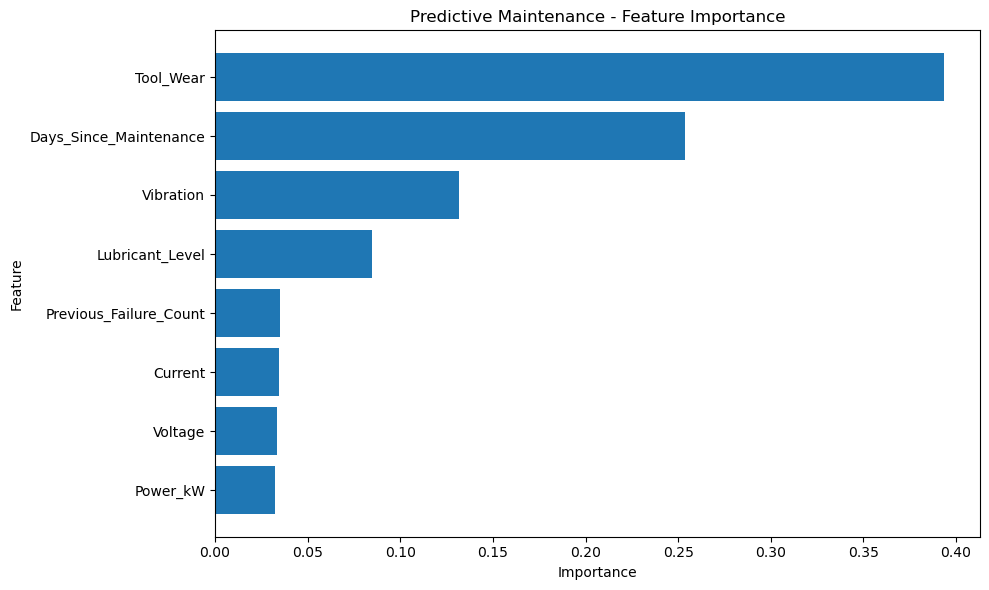

In [111]:
plt.figure(figsize=(10, 6))

plt.barh(
    maintenance_importance['Feature'],
    maintenance_importance['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Predictive Maintenance - Feature Importance')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [112]:
# Failure Predictability

# Predict probability of machine failure
failure_probability = maintenance_rf.predict_proba(X_test_m)[:, 1]

maintenance_predictions = X_test_m.copy()

maintenance_predictions['Actual_Failure'] = y_test_m.values
maintenance_predictions['Failure_Probability'] = failure_probability

In [113]:
def risk_category(probability):
    if probability < 0.30:
        return 'Low'
    elif probability < 0.60:
        return 'Medium'
    else:
        return 'High'

maintenance_predictions['Risk_Level'] = (
    maintenance_predictions['Failure_Probability']
    .apply(risk_category)
)

In [114]:
maintenance_predictions.head(10)

,Vibration,Tool_Wear,Days_Since_Maintenance,Previous_Failure_Count,Lubricant_Level,Current,Voltage,Power_kW,Actual_Failure,Failure_Probability,Risk_Level
1703,2.026865,752,156,1,82.181833,194.102856,419.981811,506.514793,1,0.575,Medium
6600,2.071709,454,9,1,95.640050,224.615099,404.467357,525.482014,0,0.005,Low
10059,2.172011,903,81,3,66.338624,207.354805,421.578368,500.818041,1,0.800,High
3534,1.582432,340,103,0,44.280383,210.270908,403.504100,515.760178,0,0.000,Low
4773,2.298002,980,113,0,84.200491,214.129739,423.841268,510.053549,1,0.670,High
1205,2.816505,226,85,1,36.453807,206.070069,428.001867,520.877604,0,0.020,Low
8785,2.555504,912,28,0,33.523362,212.619453,420.253950,534.680085,0,0.405,Medium
3220,2.402284,886,68,0,59.317628,199.923785,422.415152,515.222253,0,0.340,Medium
5981,1.977253,226,7,2,78.896819,223.536198,421.648918,514.842131,0,0.005,Low
4339,2.891424,501,30,0,20.703906,200.163702,430.649424,496.087137,0,0.050,Low


In [115]:
machine_risk = maintenance_predictions.copy()

machine_risk['Machine_ID'] = df.loc[
    X_test_m.index,
    'Machine_ID'
].values

machine_summary = (
    machine_risk
    .groupby('Machine_ID')
    .agg(
        Average_Failure_Risk=('Failure_Probability', 'mean'),
        Maximum_Failure_Risk=('Failure_Probability', 'max'),
        High_Risk_Observations=(
            'Risk_Level',
            lambda x: (x == 'High').sum()
        )
    )
    .reset_index()
)

In [116]:
machine_summary = machine_summary.sort_values(
    'Average_Failure_Risk',
    ascending=False
)

machine_summary

,Machine_ID,Average_Failure_Risk,Maximum_Failure_Risk,High_Risk_Observations
1,M10,0.229020,0.990,38
0,M1,0.217621,0.995,35
3,M3,0.214448,0.965,29
2,M2,0.198871,0.965,33
7,M7,0.186632,0.990,31
9,M9,0.184535,0.995,31
8,M8,0.177705,0.980,26
5,M5,0.176968,0.980,27
4,M4,0.167847,0.975,29
6,M6,0.165974,0.985,25


In [117]:
def maintenance_priority(probability):
    if probability >= 0.75:
        return 'Critical'
    elif probability >= 0.60:
        return 'High'
    elif probability >= 0.30:
        return 'Medium'
    else:
        return 'Low'

maintenance_predictions['Maintenance_Priority'] = (
    maintenance_predictions['Failure_Probability']
    .apply(maintenance_priority)
)

In [118]:
high_risk_cases = maintenance_predictions.sort_values(
    'Failure_Probability',
    ascending=False
)

high_risk_cases.head(10)

,Vibration,Tool_Wear,Days_Since_Maintenance,Previous_Failure_Count,Lubricant_Level,Current,Voltage,Power_kW,Actual_Failure,Failure_Probability,Risk_Level,Maintenance_Priority
9024,2.680532,903,171,1,21.988793,213.812457,419.491928,521.553765,1,0.995,High,Critical
5372,2.852059,960,171,1,31.334335,220.608037,421.111027,530.656457,1,0.995,High,Critical
8346,3.339709,830,168,2,29.394457,197.074714,422.458535,506.255982,1,0.990,High,Critical
1982,3.342830,887,149,3,22.313610,215.124270,420.232846,514.472888,1,0.990,High,Critical
3068,2.500811,771,173,3,29.998017,207.346293,420.868577,502.515508,1,0.990,High,Critical
5970,2.581412,988,145,1,32.659350,200.700700,416.237007,505.924593,1,0.990,High,Critical
2556,2.447735,932,172,2,38.060832,203.202979,419.952697,534.428555,1,0.990,High,Critical
443,3.120520,794,142,2,21.808909,212.172963,409.213651,510.623427,1,0.985,High,Critical
7528,2.833886,892,167,1,44.072868,217.541212,424.237049,514.875138,1,0.985,High,Critical
7342,2.996183,948,154,0,54.725758,199.935384,419.879059,511.958527,1,0.985,High,Critical


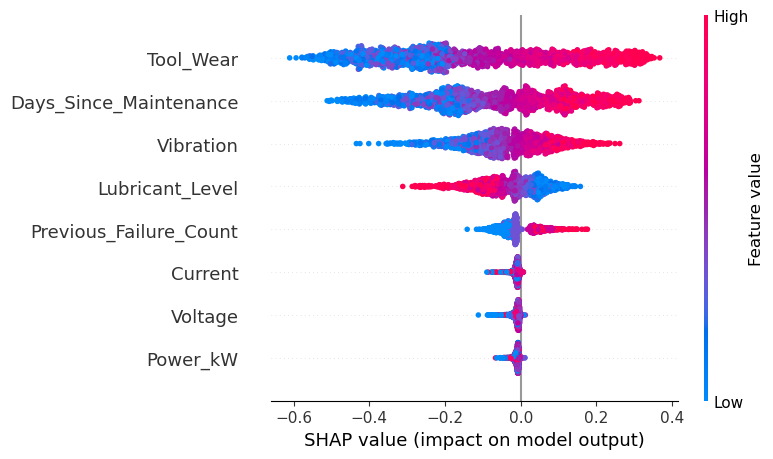

In [119]:
maintenance_explainer = shap.TreeExplainer(maintenance_rf)

maintenance_shap_values = (
    maintenance_explainer.shap_values(X_test_m)
)

if isinstance(maintenance_shap_values, list):
    maintenance_shap_fail = maintenance_shap_values[1]
else:
    maintenance_shap_fail = maintenance_shap_values[:, :, 1]

    shap.summary_plot(
    maintenance_shap_fail,
    X_test_m
)

In [120]:
def generate_maintenance_explanation(machine_id, probability, top_factors):

    if probability >= 0.75:
        risk = "HIGH"
        action = "Schedule a maintenance inspection soon."
    
    elif probability >= 0.50:
        risk = "MEDIUM"
        action = "Monitor the machine and consider a maintenance inspection."
    
    else:
        risk = "LOW"
        action = "Continue normal monitoring."

    explanation = f"""
Machine {machine_id}

Maintenance Risk: {risk}
Risk Probability: {probability:.0%}

Main contributing factors:
"""

    for factor in top_factors:
        explanation += f"- {factor}\n"

    explanation += f"""
Recommendation:
{action}
"""

    return explanation

In [121]:
example = generate_maintenance_explanation(
    machine_id="M07",
    probability=0.82,
    top_factors=[
        "High tool wear",
        "Elevated vibration",
        "Long time since maintenance"
    ]
)

print(example)


Machine M07

Maintenance Risk: HIGH
Risk Probability: 82%

Main contributing factors:
- High tool wear
- Elevated vibration
- Long time since maintenance

Recommendation:
Schedule a maintenance inspection soon.



In [122]:
example = generate_maintenance_explanation(
    machine_id="M07",
    probability=0.82,
    top_factors=[
        "High tool wear",
        "Elevated vibration",
        "Long time since maintenance"
    ]
)

print(example)

if isinstance(maintenance_shap_values, list):
    maintenance_shap_fail = maintenance_shap_values[1]
else:
    maintenance_shap_fail = maintenance_shap_values[:, :, 1]

    


Machine M07

Maintenance Risk: HIGH
Risk Probability: 82%

Main contributing factors:
- High tool wear
- Elevated vibration
- Long time since maintenance

Recommendation:
Schedule a maintenance inspection soon.



In [123]:
import numpy as np

def get_top_shap_factors(
    shap_values,
    X_data,
    sample_index,
    top_n=3
):
    
    # SHAP values for this machine/record
    sample_shap = shap_values[sample_index]
    
    # Absolute SHAP values = strength of influence
    importance = np.abs(sample_shap)
    
    # Get indexes of top factors
    top_indices = np.argsort(importance)[-top_n:][::-1]
    
    factors = []
    
    for i in top_indices:
        feature = X_data.columns[i]
        shap_value = sample_shap[i]
        feature_value = X_data.iloc[sample_index, i]
        
        direction = "increased" if shap_value > 0 else "decreased"
        
        factors.append({
            "feature": feature,
            "value": feature_value,
            "shap_value": shap_value,
            "direction": direction
        })
    
    return factors

In [124]:
def generate_maintenance_explanation(
    machine_id,
    probability,
    top_factors
):

    if probability >= 0.75:
        risk = "HIGH"
        action = "Schedule a maintenance inspection soon."
        
    elif probability >= 0.50:
        risk = "MEDIUM"
        action = "Monitor the machine and consider a maintenance inspection."
        
    else:
        risk = "LOW"
        action = "Continue normal monitoring."

    explanation = f"""
Machine {machine_id}

Maintenance Risk: {risk}
Risk Probability: {probability:.0%}

Main contributing factors:
"""

    for factor in top_factors:

        feature = factor["feature"]
        value = factor["value"]
        direction = factor["direction"]

        explanation += (
            f"- {feature} = {value:.2f} "
            f"({direction} failure risk)\n"
        )

    explanation += f"""
Recommendation:
{action}
"""

    return explanation

In [125]:
sample_index = 0
machine_id = df.loc[
    X_test_m.index[sample_index],
    "Machine_ID"
]

probability = maintenance_rf.predict_proba(
    X_test_m.iloc[[sample_index]]
)[0, 1]


top_factors = get_top_shap_factors(
    maintenance_shap_fail,
    X_test_m,
    sample_index,
    top_n=3
)

explanation = generate_maintenance_explanation(
    machine_id,
    probability,
    top_factors
)

print(explanation)



Machine M6

Maintenance Risk: MEDIUM
Risk Probability: 57%

Main contributing factors:
- Days_Since_Maintenance = 156.00 (increased failure risk)
- Lubricant_Level = 82.18 (decreased failure risk)
- Tool_Wear = 752.00 (increased failure risk)

Recommendation:
Monitor the machine and consider a maintenance inspection.



In [126]:
def show_machine_risk(sample_index):

    # Machine ID
    machine_id = df.loc[
        X_test_m.index[sample_index],
        "Machine_ID"
    ]

    # Failure probability
    probability = maintenance_rf.predict_proba(
        X_test_m.iloc[[sample_index]]
    )[0, 1]

    # Risk level
    if probability >= 0.75:
        risk = "HIGH"
    elif probability >= 0.50:
        risk = "MEDIUM"
    else:
        risk = "LOW"

    # Top 3 SHAP factors
    top_factors = get_top_shap_factors(
        maintenance_shap_fail,
        X_test_m,
        sample_index,
        top_n=3
    )

    # Display
    print("=" * 45)
    print(f"        MACHINE {machine_id}")
    print("=" * 45)

    print(f"Failure Probability: {probability:.1%}")
    print(f"Risk Level: {risk}")

    print("\nTop 3 Contributing Factors:")

    for number, factor in enumerate(top_factors, 1):

        direction = factor["direction"]

        print(
            f"{number}. {factor['feature']} "
            f"= {factor['value']:.2f} "
            f"→ {direction} failure risk"
        )

    print("\nRecommendation:")

    if risk == "HIGH":
        print("Schedule a maintenance inspection soon.")
    elif risk == "MEDIUM":
        print("Monitor the machine and consider inspection.")
    else:
        print("Continue normal monitoring.")

    print("=" * 45)

    

In [127]:
show_machine_risk(0)

        MACHINE M6
Failure Probability: 57.5%
Risk Level: MEDIUM

Top 3 Contributing Factors:
1. Days_Since_Maintenance = 156.00 → increased failure risk
2. Lubricant_Level = 82.18 → decreased failure risk
3. Tool_Wear = 752.00 → increased failure risk

Recommendation:
Monitor the machine and consider inspection.


In [128]:
sample_index = int(
    input(f"Enter a sample index (0-{len(X_test_m)-1}): ")
)

show_machine_risk(sample_index)

        MACHINE M7
Failure Probability: 0.0%
Risk Level: LOW

Top 3 Contributing Factors:
1. Days_Since_Maintenance = 20.00 → decreased failure risk
2. Tool_Wear = 381.00 → decreased failure risk
3. Vibration = 2.25 → decreased failure risk

Recommendation:
Continue normal monitoring.


In [129]:
# Select a machine/sample
sample_index = 0

machine_id = df.loc[
    X_test_m.index[sample_index],
    "Machine_ID"
]

# Get failure probability
probability = maintenance_rf.predict_proba(
    X_test_m.iloc[[sample_index]]
)[0, 1]

# Determine risk level
if probability >= 0.75:
    risk = "HIGH"
elif probability >= 0.50:
    risk = "MEDIUM"
else:
    risk = "LOW"

# Get top 3 SHAP factors
top_factors = get_top_shap_factors(
    maintenance_shap_fail,
    X_test_m,
    sample_index,
    top_n=3
)

# Display the information
print("Machine ID:", machine_id)
print("Failure Probability:", f"{probability:.1%}")
print("Risk Level:", risk)

print("\nTop Contributing Factors:")

for factor in top_factors:
    print(
        factor["feature"],
        "=",
        round(factor["value"], 2),
        "→",
        factor["direction"],
        "failure risk"
    )

Machine ID: M6
Failure Probability: 57.5%
Risk Level: MEDIUM

Top Contributing Factors:
Days_Since_Maintenance = 156 → increased failure risk
Lubricant_Level = 82.18 → decreased failure risk
Tool_Wear = 752 → increased failure risk


In [130]:
# ============================================================
# FINAL PROJECT VISUALIZATION EXPORT
# Steel Manufacturing AI Project
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

# SHAP is already used in the project
import shap


# ============================================================
# 1. CREATE IMAGES FOLDER
# ============================================================

os.makedirs("images", exist_ok=True)

print("Creating project graphs...\n")


# ============================================================
# HELPER FUNCTION
# ============================================================

def save_current_plot(filename):
    """
    Save current matplotlib figure as a high-resolution PNG.
    """
    path = os.path.join("images", filename)

    plt.savefig(
        path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    print(f"Saved: {path}")


# ============================================================
# 2. DEFECT TYPE DISTRIBUTION
# ============================================================

if "Defect_Type" in df.columns:

    defect_counts = df["Defect_Type"].value_counts()

    plt.figure(figsize=(10, 6))

    defect_counts.plot(kind="bar")

    plt.title("Steel Defect Type Distribution")
    plt.xlabel("Defect Type")
    plt.ylabel("Number of Observations")

    plt.xticks(rotation=45)
    plt.tight_layout()

    save_current_plot("01_defect_type_distribution.png")


# ============================================================
# 3. PASS / FAIL DISTRIBUTION
# ============================================================

if "Pass_Fail" in df.columns:

    quality_counts = df["Pass_Fail"].value_counts()

    plt.figure(figsize=(8, 6))

    quality_counts.plot(kind="bar")

    plt.title("Steel Quality Distribution")
    plt.xlabel("Quality Class")
    plt.ylabel("Number of Observations")

    plt.xticks(rotation=0)
    plt.tight_layout()

    save_current_plot("02_pass_fail_distribution.png")


# ============================================================
# 4. QUALITY MODEL COMPARISON
# ============================================================

quality_models = {
    "Logistic Regression": {
        "Accuracy": 0.6225,
        "ROC-AUC": 0.6321
    },
    "Decision Tree": {
        "Accuracy": 0.8315,
        "ROC-AUC": 0.8375
    },
    "Random Forest": {
        "Accuracy": 0.8490,
        "ROC-AUC": 0.9055
    }
}

model_names = list(quality_models.keys())

accuracy_values = [
    quality_models[m]["Accuracy"]
    for m in model_names
]

roc_values = [
    quality_models[m]["ROC-AUC"]
    for m in model_names
]

x = np.arange(len(model_names))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    accuracy_values,
    width,
    label="Accuracy"
)

plt.bar(
    x + width / 2,
    roc_values,
    width,
    label="ROC-AUC"
)

plt.title("Quality Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")

plt.xticks(x, model_names, rotation=15)
plt.ylim(0, 1)

plt.legend()
plt.tight_layout()

save_current_plot("03_quality_model_comparison.png")


# ============================================================
# 5. RANDOM FOREST CONFUSION MATRIX
# ============================================================

if "y_test" in globals() and "y_pred_rf" in globals():

    cm = confusion_matrix(y_test, y_pred_rf)

    plt.figure(figsize=(7, 6))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Pass", "Fail"]
    )

    disp.plot(values_format="d")

    plt.title("Random Forest - Quality Confusion Matrix")
    plt.tight_layout()

    save_current_plot("04_quality_confusion_matrix.png")


# ============================================================
# 6. QUALITY ROC CURVE
# ============================================================

if "y_test" in globals() and "y_prob_rf" in globals():

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob_rf
    )

    plt.figure(figsize=(8, 6))

    plt.plot(
        fpr,
        tpr,
        label="Random Forest (AUC = 0.9055)"
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--"
    )

    plt.title("Quality Prediction - ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.legend()
    plt.tight_layout()

    save_current_plot("05_quality_roc_curve.png")


# ============================================================
# 7. QUALITY RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

if "rf_model" in globals() and "X_train" in globals():

    quality_importance = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": rf_model.feature_importances_
    }).sort_values(
        "Importance",
        ascending=False
    ).head(15)

    plt.figure(figsize=(10, 7))

    plt.barh(
        quality_importance["Feature"][::-1],
        quality_importance["Importance"][::-1]
    )

    plt.title("Top 15 Quality Prediction Features")
    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")

    plt.tight_layout()

    save_current_plot("06_quality_feature_importance.png")


# ============================================================
# 8. MAINTENANCE RISK DISTRIBUTION
# ============================================================

if "Maintenance_Risk_Score" in df.columns:

    plt.figure(figsize=(9, 6))

    plt.hist(
        df["Maintenance_Risk_Score"],
        bins=30
    )

    plt.title("Maintenance Risk Score Distribution")
    plt.xlabel("Maintenance Risk Score")
    plt.ylabel("Number of Observations")

    plt.tight_layout()

    save_current_plot("07_maintenance_risk_distribution.png")


# ============================================================
# 9. MACHINE FAILURE TARGET DISTRIBUTION
# ============================================================

if "Machine_Failure" in df.columns:

    failure_counts = df["Machine_Failure"].value_counts()

    plt.figure(figsize=(8, 6))

    plt.bar(
        ["Normal", "Failure Risk"],
        [
            failure_counts.get(0, 0),
            failure_counts.get(1, 0)
        ]
    )

    plt.title("Simulated Machine Failure Target")
    plt.xlabel("Machine Condition")
    plt.ylabel("Number of Observations")

    plt.tight_layout()

    save_current_plot("08_machine_failure_distribution.png")


# ============================================================
# 10. MAINTENANCE FEATURE IMPORTANCE
# ============================================================

if (
    "maintenance_rf" in globals()
    and "X_train_m" in globals()
):

    maintenance_importance_export = pd.DataFrame({
        "Feature": X_train_m.columns,
        "Importance": maintenance_rf.feature_importances_
    }).sort_values(
        "Importance",
        ascending=False
    )

    plt.figure(figsize=(10, 7))

    plt.barh(
        maintenance_importance_export["Feature"][::-1],
        maintenance_importance_export["Importance"][::-1]
    )

    plt.title("Maintenance Model Feature Importance")
    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")

    plt.tight_layout()

    save_current_plot("09_maintenance_feature_importance.png")


# ============================================================
# 11. MAINTENANCE RISK LEVEL DISTRIBUTION
# ============================================================

if "maintenance_predictions" in globals():

    if "Risk_Level" in maintenance_predictions.columns:

        risk_counts = (
            maintenance_predictions["Risk_Level"]
            .value_counts()
            .reindex(
                ["Low", "Medium", "High"],
                fill_value=0
            )
        )

        plt.figure(figsize=(8, 6))

        plt.bar(
            risk_counts.index,
            risk_counts.values
        )

        plt.title("Machine Maintenance Risk Levels")
        plt.xlabel("Risk Level")
        plt.ylabel("Number of Observations")

        plt.tight_layout()

        save_current_plot("10_maintenance_risk_levels.png")


# ============================================================
# 12. MACHINE RISK COMPARISON
# ============================================================

if "machine_summary" in globals():

    machine_plot = machine_summary.sort_values(
        "Average_Failure_Risk",
        ascending=True
    )

    plt.figure(figsize=(10, 7))

    plt.barh(
        machine_plot["Machine_ID"],
        machine_plot["Average_Failure_Risk"]
    )

    plt.title("Average Maintenance Risk by Machine")
    plt.xlabel("Average Failure Probability")
    plt.ylabel("Machine")

    plt.tight_layout()

    save_current_plot("11_machine_risk_comparison.png")


# ============================================================
# 13. SHAP - QUALITY MODEL
# ============================================================

if (
    "rf_model" in globals()
    and "X_test" in globals()
):

    try:

        quality_explainer = shap.TreeExplainer(
            rf_model
        )

        quality_shap_values = (
            quality_explainer.shap_values(X_test)
        )

        if isinstance(quality_shap_values, list):

            quality_shap_fail = quality_shap_values[1]

        else:

            quality_shap_fail = (
                quality_shap_values[:, :, 1]
            )

        plt.figure()

        shap.summary_plot(
            quality_shap_fail,
            X_test,
            plot_type="bar",
            show=False
        )

        plt.title(
            "SHAP Feature Importance - Quality Failure Prediction"
        )

        plt.tight_layout()

        save_current_plot("12_shap_quality_bar.png")


        plt.figure()

        shap.summary_plot(
            quality_shap_fail,
            X_test,
            show=False
        )

        plt.title(
            "SHAP Summary - Quality Failure Prediction"
        )

        plt.tight_layout()

        save_current_plot("13_shap_quality_summary.png")

    except Exception as e:

        print(
            "Quality SHAP graph could not be saved:",
            e
        )


# ============================================================
# 14. SHAP - MAINTENANCE MODEL
# ============================================================

if (
    "maintenance_rf" in globals()
    and "X_test_m" in globals()
):

    try:

        maintenance_explainer = shap.TreeExplainer(
            maintenance_rf
        )

        maintenance_shap_values = (
            maintenance_explainer.shap_values(X_test_m)
        )

        if isinstance(
            maintenance_shap_values,
            list
        ):

            maintenance_shap_fail = (
                maintenance_shap_values[1]
            )

        else:

            maintenance_shap_fail = (
                maintenance_shap_values[:, :, 1]
            )

        plt.figure()

        shap.summary_plot(
            maintenance_shap_fail,
            X_test_m,
            plot_type="bar",
            show=False
        )

        plt.title(
            "SHAP Feature Importance - Maintenance Risk"
        )

        plt.tight_layout()

        save_current_plot("14_shap_maintenance_bar.png")


        plt.figure()

        shap.summary_plot(
            maintenance_shap_fail,
            X_test_m,
            show=False
        )

        plt.title(
            "SHAP Summary - Maintenance Risk"
        )

        plt.tight_layout()

        save_current_plot("15_shap_maintenance_summary.png")

    except Exception as e:

        print(
            "Maintenance SHAP graph could not be saved:",
            e
        )


# ============================================================
# 15. VIBRATION VS TOOL WEAR
# ============================================================

if (
    "Vibration" in df.columns
    and "Tool_Wear" in df.columns
):

    plt.figure(figsize=(9, 6))

    plt.scatter(
        df["Vibration"],
        df["Tool_Wear"],
        alpha=0.5
    )

    plt.title("Vibration vs Tool Wear")
    plt.xlabel("Vibration")
    plt.ylabel("Tool Wear")

    plt.tight_layout()

    save_current_plot("16_vibration_vs_tool_wear.png")


# ============================================================
# 16. DAYS SINCE MAINTENANCE VS FAILURE RISK
# ============================================================

if (
    "Days_Since_Maintenance" in df.columns
    and "Maintenance_Risk_Score" in df.columns
):

    plt.figure(figsize=(9, 6))

    plt.scatter(
        df["Days_Since_Maintenance"],
        df["Maintenance_Risk_Score"],
        alpha=0.5
    )

    plt.title(
        "Days Since Maintenance vs Maintenance Risk"
    )

    plt.xlabel("Days Since Maintenance")
    plt.ylabel("Maintenance Risk Score")

    plt.tight_layout()

    save_current_plot(
        "17_days_since_maintenance_vs_risk.png"
    )


# ============================================================
# 17. FINAL MESSAGE
# ============================================================

print("\n" + "=" * 60)
print("ALL PROJECT GRAPHS HAVE BEEN EXPORTED")
print("=" * 60)

print("\nFolder:")
print(os.path.abspath("images"))

print("\nOpen the 'images' folder to view all generated PNG files.")

Creating project graphs...

Saved: images\01_defect_type_distribution.png
Saved: images\02_pass_fail_distribution.png
Saved: images\03_quality_model_comparison.png
Saved: images\04_quality_confusion_matrix.png
Saved: images\05_quality_roc_curve.png
Saved: images\06_quality_feature_importance.png
Saved: images\07_maintenance_risk_distribution.png
Saved: images\08_machine_failure_distribution.png
Saved: images\09_maintenance_feature_importance.png
Saved: images\10_maintenance_risk_levels.png
Saved: images\11_machine_risk_comparison.png
Saved: images\12_shap_quality_bar.png
Saved: images\13_shap_quality_summary.png
Saved: images\14_shap_maintenance_bar.png
Saved: images\15_shap_maintenance_summary.png
Saved: images\16_vibration_vs_tool_wear.png
Saved: images\17_days_since_maintenance_vs_risk.png

ALL PROJECT GRAPHS HAVE BEEN EXPORTED

Folder:
d:\Steel Manufacturing\notebooks\images

Open the 'images' folder to view all generated PNG files.


<Figure size 700x600 with 0 Axes>